In [2]:
import os
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.family'] = 'Malgun Gothic'
basket = pd.read_csv('datasets/recommend/market/groceries_basket.csv')
print('거래(장바구니)수:', len(basket), '/상품수:', basket.shape[1])

거래(장바구니)수: 9835 /상품수: 169


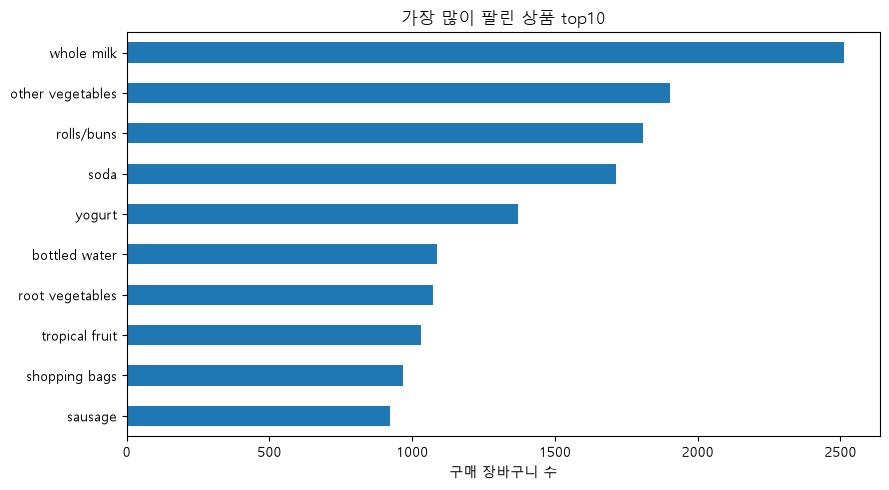

In [4]:
item_freq = basket.sum().sort_values(ascending=False)
plt.figure(figsize=(9,5))
item_freq.head(10)[::-1].plot(kind='barh')
plt.title('가장 많이 팔린 상품 top10'); plt.xlabel('구매 장바구니 수'); plt.tight_layout();plt.show()

In [5]:
print(basket.dtypes)
print(basket.head())

Instant food products    bool
UHT-milk                 bool
abrasive cleaner         bool
artif. sweetener         bool
baby cosmetics           bool
                         ... 
white bread              bool
white wine               bool
whole milk               bool
yogurt                   bool
zwieback                 bool
Length: 169, dtype: object
   Instant food products  UHT-milk  abrasive cleaner  artif. sweetener  \
0                  False     False             False             False   
1                  False     False             False             False   
2                  False     False             False             False   
3                  False     False             False             False   
4                  False     False             False             False   

   baby cosmetics  baby food   bags  baking powder  bathroom cleaner   beef  \
0           False      False  False          False             False  False   
1           False      False  False     

In [6]:
#빈발항목집합(Frequent Itemsets) 찾기
!pip install mlxtend

   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 1.4/1.4 MB 14.0 MB/s  0:00:00


In [11]:
from mlxtend.frequent_patterns import apriori, association_rules

frequent = apriori(
    basket,
    min_support=0.02,  # 최소 지지도 2%:
                       # 전체 거래 중 2% 이상 등장한 상품 조합만 추출
    use_colnames=True  # 상품을 열 번호가 아닌 실제 상품명으로 표시
)

# 각 아이템셋에 포함된 상품 개수 계산
# apply = 각 행에 함수 적용, len = 개수 세기
frequent['n_items'] = frequent['itemsets'].apply(len)

# 전체 빈발 아이템셋 수 출력
print('빈발 아이템셋 수:', len(frequent))

# \n = 줄바꿈
print('\n2개 조합 중 지지도 상위:')

# 상품이 2개인 조합만 추출한 후 지지도 내림차순 정렬
pair = frequent[frequent['n_items'] == 2].sort_values('support',ascending=False)

# 지지도가 높은 상위 6개 출력
for _, row in pair.head(6).iterrows():
    print(f"{set(row['itemsets'])} 지지도 {row['support']:.3f}")
# head(6) = 상위 6개 행 선택
# iterrows() = 데이터프레임의 각 행을 하나씩 가져옴
# _ = 행의 인덱스 번호(사용하지 않아서 _로 표시)
# row = 현재 행의 데이터


빈발 아이템셋 수: 122

2개 조합 중 지지도 상위:
{'whole milk', 'other vegetables'} 지지도 0.075
{'whole milk', 'rolls/buns'} 지지도 0.057
{'whole milk', 'yogurt'} 지지도 0.056
{'whole milk', 'root vegetables'} 지지도 0.049
{'other vegetables', 'root vegetables'} 지지도 0.047
{'yogurt', 'other vegetables'} 지지도 0.043


In [15]:
rules = association_rules(frequent, metric='lift', min_threshold=1.0) #향상도 1이상
rules = rules[rules['confidence']>=0.3].sort_values('lift', ascending=False)

# frequent[frequent['n_items'] == 2]    상품이 정확히 2개인 조합만 필터링
#.sort_values('support', ascending=False)  지지도가 높은 순서로 정렬
# pair.head(6).iterrows()   상위 6개 데이터를 한 행씩 꺼내서 반복

rules

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
114,"frozenset({whole milk, other vegetables})",frozenset({root vegetables}),0.074835,0.108998,0.023183,0.309783,2.842082,1.0,0.015026,1.290900,0.700572,0.144304,0.225347,0.261235
115,"frozenset({whole milk, root vegetables})",frozenset({other vegetables}),0.048907,0.193493,0.023183,0.474012,2.449770,1.0,0.013719,1.533320,0.622230,0.105751,0.347821,0.296912
51,frozenset({root vegetables}),frozenset({other vegetables}),0.108998,0.193493,0.047382,0.434701,2.246605,1.0,0.026291,1.426693,0.622764,0.185731,0.299078,0.339789
58,frozenset({whipped/sour cream}),frozenset({other vegetables}),0.071683,0.193493,0.028876,0.402837,2.081924,1.0,0.015006,1.350565,0.559803,0.122203,0.259569,0.276037
120,"frozenset({whole milk, yogurt})",frozenset({other vegetables}),0.056024,0.193493,0.022267,0.397459,2.054131,1.0,0.011427,1.338511,0.543633,0.097987,0.252901,0.256270
122,"frozenset({yogurt, other vegetables})",frozenset({whole milk}),0.043416,0.255516,0.022267,0.512881,2.007235,1.0,0.011174,1.528340,0.524577,0.080485,0.345695,0.300014
17,frozenset({butter}),frozenset({whole milk}),0.055414,0.255516,0.027555,0.497248,1.946053,1.0,0.013395,1.480817,0.514659,0.097237,0.324697,0.302543
46,frozenset({pork}),frozenset({other vegetables}),0.057651,0.193493,0.021657,0.375661,1.941476,1.0,0.010502,1.291779,0.514595,0.094373,0.225874,0.243795
25,frozenset({curd}),frozenset({whole milk}),0.053279,0.255516,0.026131,0.490458,1.919481,1.0,0.012517,1.461085,0.505984,0.092446,0.315577,0.296363
116,"frozenset({other vegetables, root vegetables})",frozenset({whole milk}),0.047382,0.255516,0.023183,0.489270,1.914833,1.0,0.011076,1.457687,0.501524,0.082879,0.313982,0.289999


In [17]:
# 연관규칙 생성
# metric='lift' : 향상도(lift)를 기준으로 규칙 생성
# min_threshold=1.0 : 향상도가 1 이상인 규칙만 추출
rules = association_rules(frequent,metric='lift',min_threshold=1.0)

# confidence(신뢰도)가 0.3(30%) 이상인 규칙만 선택
# lift(향상도)가 높은 순으로 내림차순 정렬
rules = rules[rules['confidence'] >= 0.3].sort_values('lift',ascending=False)

# 원본 rules를 보존하기 위해 복사본 생성
view = rules.copy()

# antecedents = 선행항목(A), 즉 먼저 산 상품
# lambda = 각 행의 상품 집합에 적용할 간단한 함수
# ', '.join(s) = 여러 상품명을 쉼표로 연결해서 하나의 문자열로 변환
view['A(산 것)'] = view['antecedents'].apply(lambda s: ', '.join(s))

# consequents = 후행항목(B), 즉 A를 산 경우 함께 사는 상품
# 상품 집합을 보기 편한 문자열로 변환
view['B(같이 삼)'] = view['consequents'].apply(lambda s: ', '.join(s))

print('연관규칙(향상도 높은 순)')

# 필요한 열만 선택
# head(8) = 향상도가 높은 상위 8개 규칙
# round(3) = 숫자를 소수점 셋째 자리까지 표시
# to_string(index=False) = DataFrame의 인덱스를 제외하고 문자열 형태로 출력
print(view[['A(산 것)', 'B(같이 삼)','support', 'confidence', 'lift']].head(8).round(3).to_string(index=False))


연관규칙(향상도 높은 순)
                      A(산 것)          B(같이 삼)  support  confidence  lift
whole milk, other vegetables  root vegetables    0.023       0.310 2.842
 whole milk, root vegetables other vegetables    0.023       0.474 2.450
             root vegetables other vegetables    0.047       0.435 2.247
          whipped/sour cream other vegetables    0.029       0.403 2.082
          whole milk, yogurt other vegetables    0.022       0.397 2.054
    yogurt, other vegetables       whole milk    0.022       0.513 2.007
                      butter       whole milk    0.028       0.497 1.946
                        pork other vegetables    0.022       0.376 1.941


In [ ]:
결과해석
#r:
whole milk + other vegetables → root vegetables
support = 0.023  → 전체 거래의 2.3%에서 우유(whole milk), 기타 채소(other vegetables), 뿌리채소(root vegetables)가 모두 함께 구매되었습니다.
confidence = 0.310 → 우유와 기타 채소를 구매한 거래 중 31.0%가 뿌리채소도 구매
lift = 2.84 → 우유와 기타 채소를 구매한 경우, 그렇지 않은 일반적인 경우보다 뿌리채소를 구매하는 경향이 약 2.84배 높다고 해석

연관규칙 분석 결과, whole milk + other vegetables → root vegetables 규칙의 향상도가 2.842로 가장 높게 나타났다. 
    이는 우유와 기타 채소를 구매한 경우 뿌리채소를 구매하는 경향이 일반적인 경우보다 약 2.84배 높음을 의미한다. 
        또한 yogurt + other vegetables → whole milk의 신뢰도가 0.513으로 나타나, 
요구르트와 기타 채소를 구매한 거래의 51.3%에서 우유도 함께 구매한 것으로 분석되었다.
    전반적으로 우유와 채소류를 중심으로 함께 구매되는 경향이 확인되었다.

# 지지도: a->b 함계 나온 비율 (너무 낮으면 드문 규칙)
# 신뢰도 : a살 때 b 도 함꼐 살 확률(높을수록 확실)
# 향상도: 우연 대비 몇 배?(1보다 크면 연관, 클수록 강함)